# Sentiment Classification with CNN (`1D Convolutional Neural Network`)

This notebook fine-tunes a pretrained **CNN** model for **3-class sentiment classification**:
- **Negative** (original label `-1` → mapped to `0`)
- **Neutral** (original label `0` → mapped to `1`)
- **Positive** (original label `1` → mapped to `2`)

---
## Table of Contents
1. Install Dependencies
2. Import Libraries
3. Load Dataset
4. Data Preprocessing
5. Train/Test Split
6. Tokenization
7. Dataset & DataLoader
8. Model Setup
9. Training Loop
10. Evaluation
11. Confusion Matrix Visualization

## 1. Install Dependencies

In [1]:
# Install / upgrade required packages
!pip install -q tensorflow scikit-learn pandas numpy matplotlib seaborn

import tensorflow as tf
print(f"TensorFlow {tf.__version__} | GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow 2.20.0 | GPU available: False


## 2. Import Libraries

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models, callbacks

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(SEED)

# ── Device ─────────────────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
print(f"Using device: {'GPU' if gpus else 'CPU'}")
if gpus:
    print(f"  GPU: {gpus[0]}")

Using device: CPU


## 3. Load Dataset

> upload `cleaned_data.csv` into the Colab session.

In [3]:
# ── Upload cleaned_data.csv from your local machine ────────────────────────────
from google.colab import files

print("Please select and upload your cleaned_data.csv file:")
uploaded = files.upload()   # opens a file-picker dialog

# Verify the expected file was uploaded
import os
if "cleaned_data.csv" not in uploaded:
    fname = list(uploaded.keys())[0]
    os.rename(fname, "cleaned_data.csv")
    print(f"Renamed '{fname}' → 'cleaned_data.csv'")
else:
    print("✅ cleaned_data.csv uploaded successfully.")

Please select and upload your cleaned_data.csv file:


Saving cleaned_data.csv to cleaned_data.csv
✅ cleaned_data.csv uploaded successfully.


In [4]:
# ── Configuration ──────────────────────────────────────────────────────────────
DATA_PATH    = "cleaned_data.csv"   # uploaded in the cell above
TEXT_COL     = "clean_review"
LABEL_COL    = "label"
VOCAB_SIZE   = 10000
MAX_LEN      = 128
EMBED_DIM    = 128
BATCH_SIZE   = 16
EPOCHS       = 10
NUM_CLASSES  = 3

LABEL_NAMES  = ["Negative", "Neutral", "Positive"]

# ── Load ───────────────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
print(f"Columns      : {df.columns.tolist()}")
df.head()

Dataset shape: (3242, 2)
Columns      : ['clean_review', 'label']


,clean_review,label
0,batu cave unforgettable blend culture spiritua...,1
1,visited place malaysia truly one iconic breath...,1
2,must visit kl walk difficult facility support ...,1
3,impressive sight arrival large statue brightly...,1
4,batu cave first discovered way really much ope...,1


## 4. Data Preprocessing

In [5]:
# ── Validate required columns ──────────────────────────────────────────────────
assert TEXT_COL  in df.columns, f"Column '{TEXT_COL}' not found in dataset."
assert LABEL_COL in df.columns, f"Column '{LABEL_COL}' not found in dataset."

# ── Drop rows with missing text or label ───────────────────────────────────────
before = len(df)
df = df.dropna(subset=[TEXT_COL, LABEL_COL])
print(f"Dropped {before - len(df)} rows with missing values. Remaining: {len(df)}")

# ── Ensure text is string type ─────────────────────────────────────────────────
df[TEXT_COL] = df[TEXT_COL].astype(str).str.strip()

# ── Drop empty strings after stripping ────────────────────────────────────────
df = df[df[TEXT_COL] != ""]

# ── Validate label values ──────────────────────────────────────────────────────
valid_labels = {-1, 0, 1}
df[LABEL_COL] = pd.to_numeric(df[LABEL_COL], errors="coerce")
df = df.dropna(subset=[LABEL_COL])
df[LABEL_COL] = df[LABEL_COL].astype(int)
invalid_mask = ~df[LABEL_COL].isin(valid_labels)
if invalid_mask.sum() > 0:
    print(f"Warning: Dropping {invalid_mask.sum()} rows with invalid labels.")
    df = df[~invalid_mask]

# ── Map labels: -1→0, 0→1, 1→2 ────────────────────────────────────────────────
label_map = {-1: 0, 0: 1, 1: 2}
df["mapped_label"] = df[LABEL_COL].map(label_map)

print("\nLabel distribution after mapping:")
print(df["mapped_label"].value_counts().sort_index()
      .rename({0: "Negative (0)", 1: "Neutral (1)", 2: "Positive (2)"}))

df.reset_index(drop=True, inplace=True)
print(f"\nFinal dataset size: {len(df)} rows")

Dropped 0 rows with missing values. Remaining: 3242

Label distribution after mapping:
mapped_label
Negative (0)     261
Neutral (1)      448
Positive (2)    2533
Name: count, dtype: int64

Final dataset size: 3242 rows


## 5. Train / Test Split (80 / 20, stratified)

In [6]:
texts  = df[TEXT_COL].tolist()
labels = df["mapped_label"].tolist()

train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=SEED,
    stratify=labels,        # preserve class distribution
)

print(f"Training samples : {len(train_texts)}")
print(f"Test samples     : {len(test_texts)}")

# Verify stratification
train_dist = pd.Series(train_labels).value_counts(normalize=True).sort_index()
test_dist  = pd.Series(test_labels).value_counts(normalize=True).sort_index()
print("\nClass proportions (train vs test):")
print(pd.DataFrame({"Train": train_dist, "Test": test_dist}).rename(
    index={0: "Negative", 1: "Neutral", 2: "Positive"}))

Training samples : 2593
Test samples     : 649

Class proportions (train vs test):
             Train      Test
Negative  0.080602  0.080123
Neutral   0.138064  0.138675
Positive  0.781334  0.781202


## 6. Tokenization & Sequence Padding

In [7]:
# Build vocabulary from training text only
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

actual_vocab_size = min(VOCAB_SIZE, len(tokenizer.word_index) + 1)

print(f"Tokenizer fitted on training data")
print(f"Vocabulary size : {actual_vocab_size}")

# Quick sanity check
sample_seq = tokenizer.texts_to_sequences(["This place was amazing and beautiful"])
print(f"Sample sequence: {sample_seq}")

Tokenizer fitted on training data
Vocabulary size : 7328
Sample sequence: [[1, 2, 1, 39, 1, 10]]


## 7. Dataset Preparation

In [8]:
# ── Convert texts to padded sequences ──────────────────────────────────────────
X_train = pad_sequences(
    tokenizer.texts_to_sequences(train_texts),
    maxlen=MAX_LEN, padding="post", truncating="post"
)
X_test = pad_sequences(
    tokenizer.texts_to_sequences(test_texts),
    maxlen=MAX_LEN, padding="post", truncating="post"
)

y_train = np.array(train_labels)
y_test  = np.array(test_labels)

print("Building training dataset...")
print("Building test dataset...")
print()
print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"Train batches : {len(X_train) // BATCH_SIZE}")
print(f"Test batches  : {len(X_test) // BATCH_SIZE}")

Building training dataset...
Building test dataset...

X_train shape : (2593, 128)
X_test shape  : (649, 128)
Train batches : 162
Test batches  : 40


## 8. Model Setup (CNN Architecture)

In [9]:
# ── Build the CNN model ──────────────────────────────────────────────────────
model = models.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    layers.Embedding(input_dim=actual_vocab_size, output_dim=EMBED_DIM),
    layers.Conv1D(filters=128, kernel_size=5, activation="relu"),
    layers.GlobalMaxPooling1D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation="softmax"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

total_params = model.count_params()
print(f"\nModel parameters : {total_params:,}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 128, 128)       │       937,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 124, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,028,483 (3.92 MB)

 Trainable params: 1,028,483 (3.92 MB)

 Non-trainable params: 0 (0.00 B)


Model parameters : 1,028,483


## 9. Training Loop

In [10]:
# ── Training ───────────────────────────────────────────────────────────────────
BEST_MODEL_PATH = "best_cnn_sentiment.keras"

checkpoint_cb = callbacks.ModelCheckpoint(
    BEST_MODEL_PATH, monitor="val_loss", save_best_only=True, verbose=0
)
earlystop_cb = callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

print("Starting training...\n")

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[checkpoint_cb, earlystop_cb],
    verbose=0,
)

# ── Print epoch-by-epoch summary in BERT-notebook style ─────────────────────────
best_val_loss = float("inf")
for epoch in range(len(history.history["loss"])):
    train_loss = history.history["loss"][epoch]
    val_loss   = history.history["val_loss"][epoch]
    val_acc    = history.history["val_accuracy"][epoch]

    print(f"── Epoch {epoch+1}/{EPOCHS} ──────────────────────────────")
    print(f"  Train Loss : {train_loss:.4f}")
    print(f"  Val   Loss : {val_loss:.4f}")
    print(f"  Val   Acc  : {val_acc:.4f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        print(f"  ✅ Best model saved (val_loss={val_loss:.4f})")
    print()

Starting training...

── Epoch 1/10 ──────────────────────────────
  Train Loss : 0.6893
  Val   Loss : 0.5357
  Val   Acc  : 0.7812
  ✅ Best model saved (val_loss=0.5357)

── Epoch 2/10 ──────────────────────────────
  Train Loss : 0.4248
  Val   Loss : 0.4435
  Val   Acc  : 0.8151
  ✅ Best model saved (val_loss=0.4435)

── Epoch 3/10 ──────────────────────────────
  Train Loss : 0.2140
  Val   Loss : 0.4850
  Val   Acc  : 0.8336

── Epoch 4/10 ──────────────────────────────
  Train Loss : 0.0958
  Val   Loss : 0.6431
  Val   Acc  : 0.8475

── Epoch 5/10 ──────────────────────────────
  Train Loss : 0.0422
  Val   Loss : 0.6976
  Val   Acc  : 0.8459



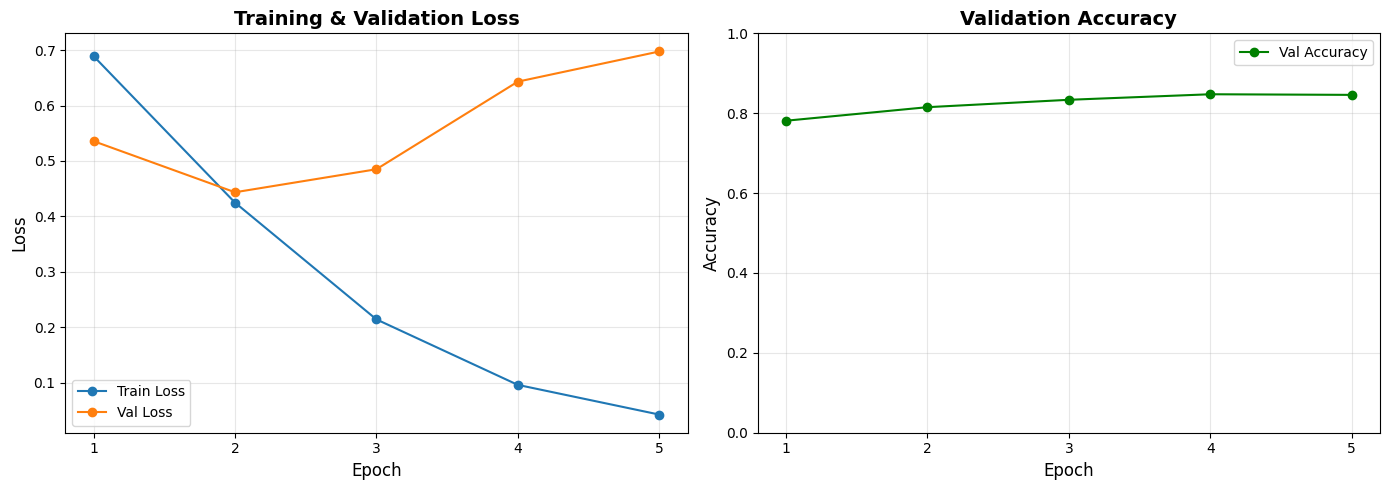

Training history plot saved to 'training_history_cnn.png'


In [11]:
# ── Plot training history ────────────────────────────────────────────────────
epochs_range = range(1, len(history.history["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Train vs Val Loss ---
axes[0].plot(epochs_range, history.history["loss"], marker="o", label="Train Loss")
axes[0].plot(epochs_range, history.history["val_loss"], marker="o", label="Val Loss")
axes[0].set_title("Training & Validation Loss", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("Loss", fontsize=12)
axes[0].set_xticks(list(epochs_range))
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Plot 2: Val Accuracy ---
axes[1].plot(epochs_range, history.history["val_accuracy"], marker="o", color="green", label="Val Accuracy")
axes[1].set_title("Validation Accuracy", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Epoch", fontsize=12)
axes[1].set_ylabel("Accuracy", fontsize=12)
axes[1].set_xticks(list(epochs_range))
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_history_cnn.png", dpi=150, bbox_inches="tight")
plt.show()
print("Training history plot saved to 'training_history_cnn.png'")

## 10. Evaluation on Test Set

In [12]:
# ── Load the best checkpoint ───────────────────────────────────────────────────
model = tf.keras.models.load_model(BEST_MODEL_PATH)
print(f"Loaded best model from '{BEST_MODEL_PATH}'\n")

# ── Run inference ──────────────────────────────────────────────────────────────
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test

# ── Compute metrics ────────────────────────────────────────────────────────────
accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
recall    = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1        = f1_score(y_true, y_pred, average="macro", zero_division=0)

print("═════════════════════════════════════════════")
print("         TEST SET METRICS (macro avg)")
print("═════════════════════════════════════════════")
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("═════════════════════════════════════")

print("\nDetailed classification report:")
print(classification_report(y_true, y_pred, target_names=LABEL_NAMES))

Loaded best model from 'best_cnn_sentiment.keras'

═════════════════════════════════════════════
         TEST SET METRICS (macro avg)
═════════════════════════════════════════════
  Accuracy  : 0.8151
  Precision : 0.6566
  Recall    : 0.5289
  F1-Score  : 0.5261
═════════════════════════════════════

Detailed classification report:
              precision    recall  f1-score   support

    Negative       0.62      0.10      0.17        52
     Neutral       0.45      0.56      0.50        90
    Positive       0.89      0.93      0.91       507

    accuracy                           0.82       649
   macro avg       0.66      0.53      0.53       649
weighted avg       0.81      0.82      0.80       649



## 11. Confusion Matrix Visualization

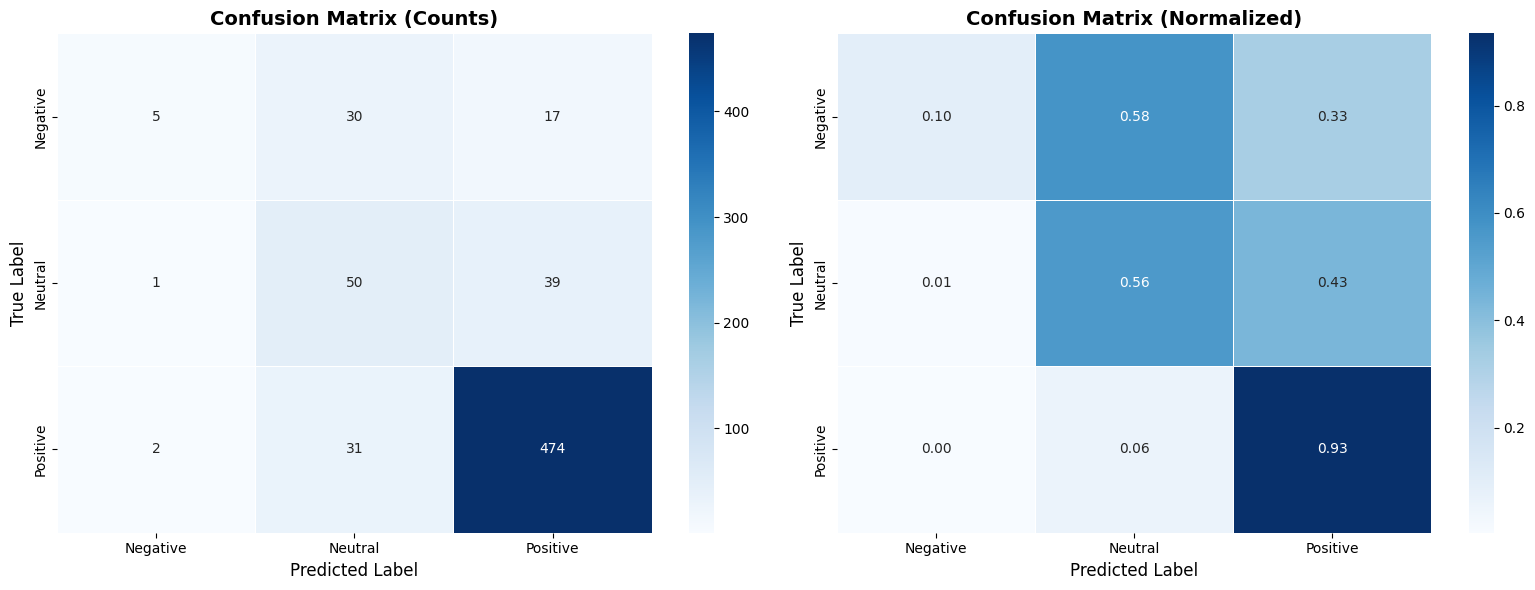

Confusion matrix saved to 'confusion_matrix_cnn.png'


In [13]:
# ── Raw counts ────────────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: raw counts ---
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES,
    ax=axes[0],
    linewidths=0.5,
)
axes[0].set_title("Confusion Matrix (Counts)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Predicted Label", fontsize=12)
axes[0].set_ylabel("True Label", fontsize=12)

# --- Plot 2: row-normalised (recall per class) ---
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES,
    ax=axes[1],
    linewidths=0.5,
)
axes[1].set_title("Confusion Matrix (Normalized)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Predicted Label", fontsize=12)
axes[1].set_ylabel("True Label", fontsize=12)

plt.tight_layout()
plt.savefig("confusion_matrix_cnn.png", dpi=150, bbox_inches="tight")
plt.show()
print("Confusion matrix saved to 'confusion_matrix_cnn.png'")

In [14]:
import pickle
from google.colab import files

# Save tokenizer
with open("cnn_tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

# Download both files
files.download("best_cnn_sentiment.keras")
files.download("cnn_tokenizer.pkl")
print("Done! Place both files in your models/ folder.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done! Place both files in your models/ folder.
